# Fermi-Dirac Electronic Occupations

This notebook computes finite-temperature electronic occupations for a tight-binding chain. The physics target is the Fermi-Dirac matrix function

$$f(H)=\frac{1}{1+e^{\beta(H-\mu I)}}.$$

The notebook is a near-pure package client: it constructs a finite tight-binding Hamiltonian, calls `fermi_dirac_occupation_workflow`, and compares the polynomial occupation operator with the exact dense spectral reference returned by the package.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies finite-temperature occupations in a one-dimensional tight-binding model with a weak periodic onsite potential.

**QSVT implementation.** The package workflow rescales the Hamiltonian, fits a bounded polynomial approximation to the Fermi-Dirac occupation function, applies it as a spectral matrix function, and returns dense reference diagnostics.

**Classical reference and quantum relevance.** The exact dense occupation operator validates the finite example. In a QSVT setting, the same polynomial occupation function is the transform core once a block encoding of the electronic Hamiltonian and an appropriate readout model are supplied.

## Variable definitions

- `n_sites`: number of tight-binding sites.
- `onsite`: periodic onsite-potential pattern.
- `H`: tight-binding Hamiltonian.
- `chemical_potential`: Fermi level.
- `beta`: inverse-temperature parameter.
- `result`: package workflow result.
- `rho_exact`, `rho_poly`: exact and polynomial one-particle occupation operators.
- `particle_number_exact`, `particle_number_poly`: exact and polynomial particle numbers.
- `fermi_exact_values`, `fermi_poly_values`: occupations on exact eigenvalues.
- `site_density_exact`, `site_density_poly`: site occupations from the density matrices.
- `fig`, `axes`, and similar names are plotting helpers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.algorithms import fermi_dirac_occupation_workflow
from qsvt.hamiltonians import tight_binding_chain
from qsvt.polynomials import eval_polynomial
from qsvt.spectral import eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_sites = 18
site = np.arange(n_sites)
onsite = 0.25 * np.cos(2 * np.pi * site / n_sites)
H = tight_binding_chain(n_sites, hopping=1.0, onsite=onsite, periodic=True)

chemical_potential = 0.15
beta = 6.0

result = fermi_dirac_occupation_workflow(
    H,
    chemical_potential=chemical_potential,
    beta=beta,
    degree=28,
    num_points=1601,
)

rho_poly = result.polynomial_occupation_operator
rho_exact = result.reference_occupation_operator
particle_number_poly = np.real(result.particle_number)
particle_number_exact = np.real(result.reference_particle_number)
occupation_error = result.operator_relative_error

print(f"Occupation Error: {occupation_error}")
print(f"Exact Particle Number [electrons]: {particle_number_exact}")
print(f"Polynomial Particle Number [electrons]: {particle_number_poly}")

Occupation Error: 0.00040589862385073276
Exact Particle Number [electrons]: 9.385723227081577
Polynomial Particle Number [electrons]: 9.386398855727302


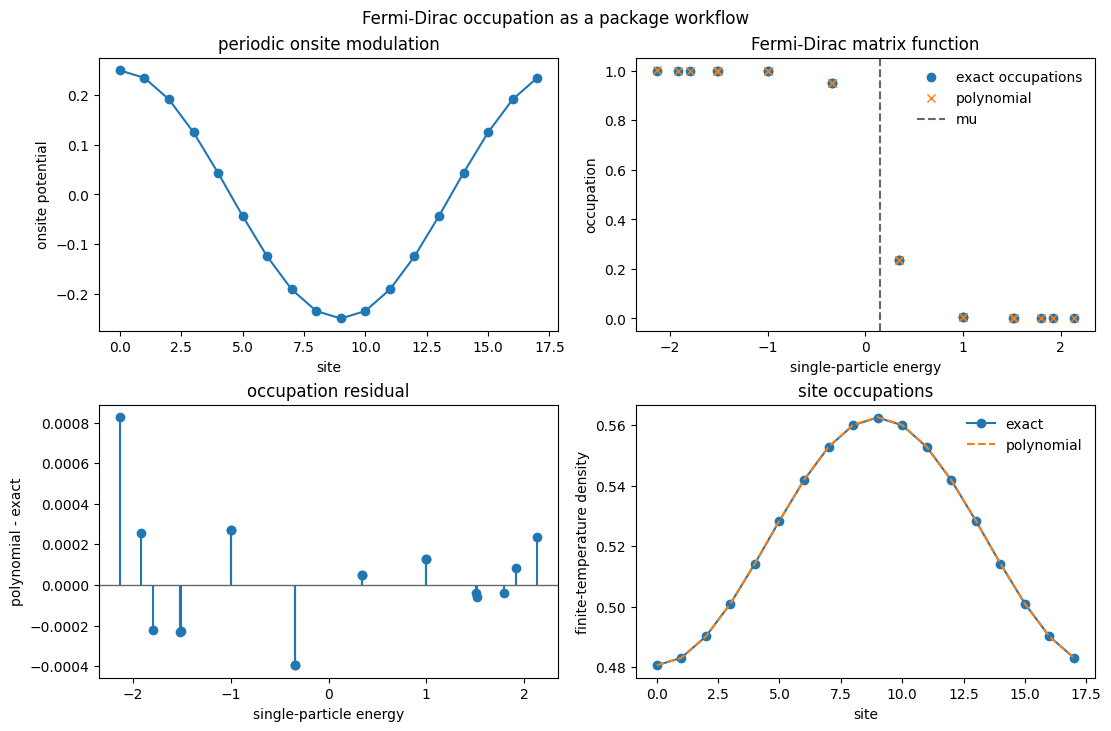

In [3]:
evals, _ = eigh_hermitian(H)
scaled_evals = np.linalg.eigvalsh(result.scaled_operator.matrix)
fermi_exact_values = np.linalg.eigvalsh(rho_exact)[::-1]
fermi_poly_values = eval_polynomial(result.coeffs, scaled_evals)
site_density_exact = np.real(np.diag(rho_exact))
site_density_poly = np.real(np.diag(rho_poly))
occupation_residual = fermi_poly_values - fermi_exact_values

fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), constrained_layout=True)

axes[0, 0].plot(site, onsite, "o-")
axes[0, 0].set_xlabel("site")
axes[0, 0].set_ylabel("onsite potential")
axes[0, 0].set_title("periodic onsite modulation")

axes[0, 1].plot(evals, fermi_exact_values, "o", label="exact occupations")
axes[0, 1].plot(evals, fermi_poly_values, "x", label="polynomial")
axes[0, 1].axvline(chemical_potential, color="0.4", linestyle="--", label="mu")
axes[0, 1].set_xlabel("single-particle energy")
axes[0, 1].set_ylabel("occupation")
axes[0, 1].set_title("Fermi-Dirac matrix function")
axes[0, 1].legend(frameon=False)

axes[1, 0].stem(evals, occupation_residual, basefmt=" ")
axes[1, 0].axhline(0.0, color="0.4", linewidth=1.0)
axes[1, 0].set_xlabel("single-particle energy")
axes[1, 0].set_ylabel("polynomial - exact")
axes[1, 0].set_title("occupation residual")

axes[1, 1].plot(site, site_density_exact, "o-", label="exact")
axes[1, 1].plot(site, site_density_poly, "--", label="polynomial")
axes[1, 1].set_xlabel("site")
axes[1, 1].set_ylabel("finite-temperature density")
axes[1, 1].set_title("site occupations")
axes[1, 1].legend(frameon=False)

fig.suptitle("Fermi-Dirac occupation as a package workflow")
plt.show()

In [4]:
report = result.as_report()
assert report["mode"] == "fermi-dirac-occupation-workflow"
assert occupation_error < 0.01
assert abs(particle_number_poly - particle_number_exact) < 0.03
assert np.all(fermi_poly_values > -0.02)
assert np.all(fermi_poly_values < 1.02)

print(f"relative_density_matrix_error: {occupation_error:.4f}")
print(f"exact_particle_number [electrons]: {particle_number_exact:.3f}")
print(f"polynomial_particle_number [electrons]: {particle_number_poly:.3f}")
print("validation: passed")

relative_density_matrix_error: 0.0004
exact_particle_number [electrons]: 9.386
polynomial_particle_number [electrons]: 9.386
validation: passed
